In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", 200)
np.random.seed(16481003)
print(os.getcwd())

C:\Users\iamja\WFU_Coding\WFU-T4-BofA-Project\src\models\isolation_forest


---
## Stage 1 — Load Per-Bank Absolute Value Datasets

Each file has **FFIEC call code features as rows** and **quarters as columns**.  
We transpose each file so that quarters become rows and features become columns —  
matching the (observations × features) format expected by Isolation Forest.

Unlike `ffiec_v2.csv` which contained quarter-over-quarter *changes* for many banks,  
these datasets contain **absolute balance sheet / income statement values** for 6 major banks.

In [2]:
DATA_DIR = r"..\..\..\data\split_banks_absolute"

BANK_FILE_MAP = {
    852218:  "ffiec_jpmorgan_chase_bank_features.csv",
    476810:  "ffiec_citibank_features.csv",
    480228:  "ffiec_bank_of_america_features.csv",
    451965:  "ffiec_wells_fargo_bank_features.csv",
    1456501: "ffiec_morgan_stanley_bank_features.csv",
    2182786: "ffiec_goldman_sachs_bank_usa_features.csv",
}

BANK_NAMES = {
    852218:  "JPMorgan Chase Bank",
    476810:  "Citibank",
    480228:  "Bank of America",
    451965:  "Wells Fargo Bank",
    1456501: "Morgan Stanley Bank",
    2182786: "Goldman Sachs Bank USA",
}

# Load each file, transpose so shape is (quarters × features), add metadata
bank_dfs = {}
for bank_id, fname in BANK_FILE_MAP.items():
    path = os.path.join(DATA_DIR, fname)
    df_raw = pd.read_csv(path, index_col=0)          # (features × quarters)
    df_T   = df_raw.T.copy()                          # (quarters × features)
    df_T.index.name = "quarter"
    df_T.index = pd.to_datetime(df_T.index, format="%m/%d/%Y")
    bank_dfs[bank_id] = df_T
    print(f"{BANK_NAMES[bank_id]:30s}  {df_T.shape[0]:3d} quarters  {df_T.shape[1]:3d} features"
          f"  [{df_T.index[0].date()} → {df_T.index[-1].date()}]")

JPMorgan Chase Bank              99 quarters  404 features  [2001-03-31 → 2025-09-30]
Citibank                         99 quarters  421 features  [2001-03-31 → 2025-09-30]
Bank of America                  99 quarters  430 features  [2001-03-31 → 2025-09-30]
Wells Fargo Bank                 99 quarters  409 features  [2001-03-31 → 2025-09-30]
Morgan Stanley Bank              99 quarters   87 features  [2001-03-31 → 2025-09-30]
Goldman Sachs Bank USA           68 quarters  189 features  [2008-12-31 → 2025-09-30]


---
## Stage 2 — Data Quality Check

In [3]:
for bank_id, df in bank_dfs.items():
    null_pct = df.isnull().mean().mean() * 100
    zero_pct = (df == 0).mean().mean() * 100
    print(f"{BANK_NAMES[bank_id]:30s}  null={null_pct:.1f}%  zeros={zero_pct:.1f}%")

JPMorgan Chase Bank             null=0.0%  zeros=12.5%
Citibank                        null=0.0%  zeros=13.8%
Bank of America                 null=0.0%  zeros=15.8%
Wells Fargo Bank                null=0.0%  zeros=14.1%
Morgan Stanley Bank             null=0.0%  zeros=24.7%
Goldman Sachs Bank USA          null=0.0%  zeros=29.7%


---
## Stage 3 — Feature Overlap Across Banks

Because banks differ in which FFIEC call codes they report, feature sets vary.  
We note the common core for reference, but each bank's model trains only on that bank's own features —  
no cross-bank feature alignment is needed for the per-bank Isolation Forest approach.

In [4]:
feature_sets = {bid: set(df.columns) for bid, df in bank_dfs.items()}
common_features = set.intersection(*feature_sets.values())
union_features  = set.union(*feature_sets.values())

print(f"Features common to ALL banks : {len(common_features)}")
print(f"Total unique features (union): {len(union_features)}")
print()
for bid, feats in feature_sets.items():
    print(f"  {BANK_NAMES[bid]:30s} {len(feats):4d} features")

Features common to ALL banks : 83
Total unique features (union): 509

  JPMorgan Chase Bank             404 features
  Citibank                        421 features
  Bank of America                 430 features
  Wells Fargo Bank                409 features
  Morgan Stanley Bank              87 features
  Goldman Sachs Bank USA          189 features


---
## Stage 4 — Preprocessing Notes: Absolute Values vs. QoQ Changes

| Aspect | `ffiec_v2` (prior) | These datasets |
|---|---|---|
| Values | Quarter-over-quarter % change | **Absolute dollar amounts** |
| Scale | Already normalised (roughly) | Raw levels — StandardScaler critical |
| Stationarity | Changes are more stationary | Levels carry trend; scaling handles this |
| Anomaly signal | Sudden *rate-of-change* spikes | Unusual *levels* relative to own history |

**Implication:** Isolation Forest on absolute values flags quarters where a bank's balance sheet  
composition looks structurally unusual compared to its own history — a different, complementary  
lens to the QoQ-change model.

---
## Stage 5a — Methodology: Walk-Forward Train/Test Split

### Limitation of the baseline model
The baseline (Stages 5–14) trains and scores on the **same data**.  Every quarter is
both a training observation and a scored observation, so anomaly flags are not truly
out-of-sample.  For exploratory research this is acceptable, but it inflates confidence
in the scores.

### Walk-forward approach
For each bank independently:
1. Sort quarters chronologically.
2. Use the **first 80 %** of quarters as the training window.
3. Score only the **held-out 20 %** (the most recent quarters).

This means the model never "sees" the quarters it is scoring during training —
a more honest evaluation of generalisation.

> **Trade-off**: The test window is short (~10–15 quarters per bank).  Anomalies
> that occurred in the training window (e.g. GFC for banks with data back to 2001)
> are not scored here.  The baseline model remains the primary output; the
> walk-forward scores are a *methodological robustness check*.


In [5]:
# ── Walk-Forward (80/20) Out-of-Sample Scoring ───────────────────────────────
WF_CONTAMINATION = 0.05
WF_N_ESTIMATORS  = 200
MIN_QUARTERS = 20

wf_results = []

print("Walk-forward out-of-sample scoring (strict 80 % train per bank)...\n")

for bank_id, df in bank_dfs.items():
    name = BANK_NAMES[bank_id]
    n    = len(df)

    split_idx = int(np.floor(n * 0.80))
    if split_idx < MIN_QUARTERS:
        print(f"  SKIP  {name}: training window only {split_idx} quarters")
        continue

    X_train = df.values[:split_idx]
    X_test  = df.values[split_idx:]
    q_test  = df.index[split_idx:]

    if len(X_test) == 0:
        print(f"  SKIP  {name}: no test quarters after split")
        continue

    pipe_wf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("iso",     IsolationForest(
                        n_estimators=WF_N_ESTIMATORS,
                        contamination=WF_CONTAMINATION,
                        random_state=16481003)),
    ])
    pipe_wf.fit(X_train)

    X_test_tr   = pipe_wf[:-1].transform(X_test)
    raw_scores  = pipe_wf.named_steps["iso"].score_samples(X_test_tr)
    anom_scores = -raw_scores
    is_anomaly  = (pipe_wf.predict(X_test_tr) == -1).astype(int)

    wf_results.append(pd.DataFrame({
        "IDRSSD":       bank_id,
        "bank_name":    name,
        "quarter":      q_test.strftime("%m/%d/%Y"),
        "wf_anom_score":anom_scores,
        "wf_is_anomaly":is_anomaly,
        "train_quarters": split_idx,
        "test_quarters":  len(X_test),
    }))

    print(f"  {name:30s}  train={split_idx:3d}  test={len(X_test):3d}  "
          f"train_end={df.index[split_idx-1].date()}  "
          f"anomalies={is_anomaly.sum()} ({is_anomaly.mean():.1%})")

wf_results_df = pd.concat(wf_results, ignore_index=True)


# ── Summary (merge with baseline happens after Stage 9) ──────────────────────
print(f"\nTotal test-window observations : {len(wf_results_df)}")
print(f"Walk-forward anomalies flagged : {wf_results_df['wf_is_anomaly'].sum()}")
print("\nWalk-Forward Anomalies (test window only):")
print(wf_results_df[wf_results_df['wf_is_anomaly']==1]
      .sort_values('wf_anom_score', ascending=False)
      [['bank_name','quarter','wf_anom_score','wf_is_anomaly']]
      .to_string(index=False))


'''# ── Merge with baseline scores for comparison ─────────────────────────────────
wf_compare = wf_results_df.merge(
    results[['IDRSSD','quarter','anom_score','adjusted_score','is_anomaly']],
    on=['IDRSSD','quarter'], how='left'
)
wf_compare['score_delta'] = wf_compare['wf_anom_score'] - wf_compare['anom_score']
wf_compare['label_agree'] = (wf_compare['wf_is_anomaly'] == wf_compare['is_anomaly']).astype(int)

print(f"\nTotal test-window observations : {len(wf_results_df)}")
print(f"Walk-forward anomalies flagged : {wf_results_df['wf_is_anomaly'].sum()}")
print(f"Label agreement with baseline  : {wf_compare['label_agree'].mean():.1%}")

print("\nWalk-Forward Anomalies (test window only):")
print(wf_results_df[wf_results_df['wf_is_anomaly']==1]
      .sort_values('wf_anom_score', ascending=False)
      [['bank_name','quarter','wf_anom_score','wf_is_anomaly']]
      .to_string(index=False))'''


Walk-forward out-of-sample scoring (strict 80 % train per bank)...

  JPMorgan Chase Bank             train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Citibank                        train= 79  test= 20  train_end=2020-09-30  anomalies=20 (100.0%)
  Bank of America                 train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Wells Fargo Bank                train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Morgan Stanley Bank             train= 79  test= 20  train_end=2020-09-30  anomalies=0 (0.0%)
  Goldman Sachs Bank USA          train= 54  test= 14  train_end=2022-03-31  anomalies=0 (0.0%)

Total test-window observations : 114
Walk-forward anomalies flagged : 20

Walk-Forward Anomalies (test window only):
bank_name    quarter  wf_anom_score  wf_is_anomaly
 Citibank 09/30/2025       0.574116              1
 Citibank 12/31/2024       0.569082              1
 Citibank 12/31/2023       0.567698              1
 Citibank 09/30/2024       0.56

'# ── Merge with baseline scores for comparison ─────────────────────────────────\nwf_compare = wf_results_df.merge(\n    results[[\'IDRSSD\',\'quarter\',\'anom_score\',\'adjusted_score\',\'is_anomaly\']],\n    on=[\'IDRSSD\',\'quarter\'], how=\'left\'\n)\nwf_compare[\'score_delta\'] = wf_compare[\'wf_anom_score\'] - wf_compare[\'anom_score\']\nwf_compare[\'label_agree\'] = (wf_compare[\'wf_is_anomaly\'] == wf_compare[\'is_anomaly\']).astype(int)\n\nprint(f"\nTotal test-window observations : {len(wf_results_df)}")\nprint(f"Walk-forward anomalies flagged : {wf_results_df[\'wf_is_anomaly\'].sum()}")\nprint(f"Label agreement with baseline  : {wf_compare[\'label_agree\'].mean():.1%}")\n\nprint("\nWalk-Forward Anomalies (test window only):")\nprint(wf_results_df[wf_results_df[\'wf_is_anomaly\']==1]\n      .sort_values(\'wf_anom_score\', ascending=False)\n      [[\'bank_name\',\'quarter\',\'wf_anom_score\',\'wf_is_anomaly\']]\n      .to_string(index=False))'

---
## Stage 5 — Bank-Specific Isolation Forest Models

Each bank gets its own model trained on **all available quarters** for that bank.  
This is an unsupervised, one-class approach: the model learns what "normal" looks like  
for each institution and scores every quarter on how far it deviates.

In [6]:
CONTAMINATION = 0.05   # Expected anomaly proportion per bank
N_ESTIMATORS  = 200
MIN_QUARTERS  = 20

all_results = []
bank_models = {}

print("Training Isolation Forest models (absolute values)...\n")

for bank_id, df in bank_dfs.items():
    name = BANK_NAMES[bank_id]

    if len(df) < MIN_QUARTERS:
        print(f"  SKIP  {name}: only {len(df)} quarters (need ≥{MIN_QUARTERS})")
        continue

    X = df.values

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("iso",     IsolationForest(
                        n_estimators=N_ESTIMATORS,
                        contamination=CONTAMINATION,
                        random_state=16481003
                    ))
    ])

    pipeline.fit(X)

    raw_scores   = pipeline.named_steps["iso"].score_samples(
                       pipeline[:-1].transform(X))           # lower = more anomalous
    anom_scores  = -raw_scores                               # higher = more anomalous
    is_anomaly   = (pipeline.predict(X) == -1).astype(int)

    bank_result = pd.DataFrame({
        "IDRSSD":     bank_id,
        "bank_name":  name,
        "quarter":    df.index.strftime("%m/%d/%Y"),
        "anom_score": anom_scores,
        "is_anomaly": is_anomaly,
    })

    all_results.append(bank_result)
    bank_models[bank_id] = {"pipeline": pipeline, "df": df}
    print(f"  OK    {name:30s}  {len(df):3d} quarters  "
          f"anomalies={is_anomaly.sum():2d} ({is_anomaly.mean():.1%})")

results = pd.concat(all_results, ignore_index=True)
print(f"\nTotal observations: {len(results)}  |  Total anomalies: {results['is_anomaly'].sum()}")

Training Isolation Forest models (absolute values)...

  OK    JPMorgan Chase Bank              99 quarters  anomalies= 5 (5.1%)
  OK    Citibank                         99 quarters  anomalies= 5 (5.1%)
  OK    Bank of America                  99 quarters  anomalies= 5 (5.1%)
  OK    Wells Fargo Bank                 99 quarters  anomalies= 5 (5.1%)
  OK    Morgan Stanley Bank              99 quarters  anomalies= 5 (5.1%)
  OK    Goldman Sachs Bank USA           68 quarters  anomalies= 4 (5.9%)

Total observations: 563  |  Total anomalies: 29


---
## Stage 6 — Score Distribution & Sanity Checks

C:\Users\iamja\AppData\Local\Temp\ipykernel_5448\1576508247.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_bank, labels=[b.replace(' Bank','').replace(' USA','') for b in bank_order], vert=True)


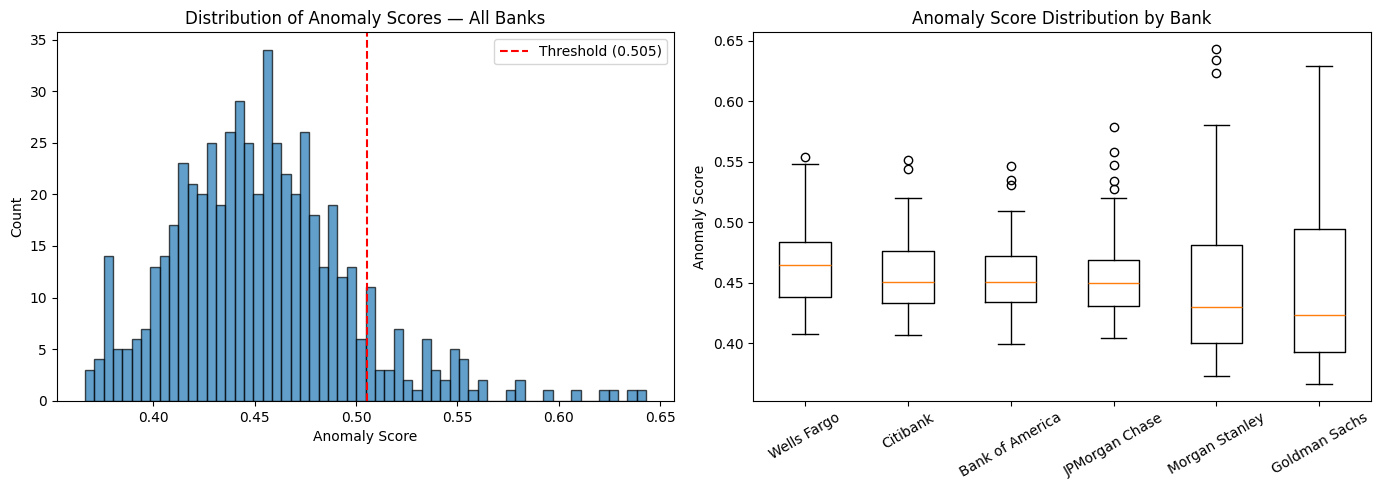


Top 20 anomalies (all banks):
             bank_name    quarter  anom_score  is_anomaly
   Morgan Stanley Bank 12/31/2024    0.643022           1
   Morgan Stanley Bank 09/30/2025    0.634126           1
Goldman Sachs Bank USA 12/31/2024    0.629037           1
   Morgan Stanley Bank 12/31/2023    0.623297           1
Goldman Sachs Bank USA 09/30/2025    0.609191           1
Goldman Sachs Bank USA 12/31/2023    0.593549           1
   Morgan Stanley Bank 06/30/2025    0.580277           1
   JPMorgan Chase Bank 09/30/2025    0.578607           1
   Morgan Stanley Bank 09/30/2024    0.576015           1
Goldman Sachs Bank USA 06/30/2025    0.562494           1
Goldman Sachs Bank USA 12/31/2022    0.561719           0
   JPMorgan Chase Bank 12/31/2024    0.557962           1
   Morgan Stanley Bank 09/30/2023    0.554588           0
      Wells Fargo Bank 09/30/2025    0.553699           1
              Citibank 12/31/2008    0.551329           1
   Morgan Stanley Bank 03/31/2025    0.55

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(results['anom_score'], bins=60, edgecolor='black', alpha=0.7)
thresh = results[results['is_anomaly']==1]['anom_score'].min()
axes[0].axvline(thresh, color='red', linestyle='--', label=f'Threshold ({thresh:.3f})')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Anomaly Scores — All Banks')
axes[0].legend()

# Boxplot by bank
bank_order = (results.groupby('bank_name')['anom_score']
              .median().sort_values(ascending=False).index.tolist())
data_by_bank = [results[results['bank_name']==b]['anom_score'].values for b in bank_order]
axes[1].boxplot(data_by_bank, labels=[b.replace(' Bank','').replace(' USA','') for b in bank_order], vert=True)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Anomaly Score Distribution by Bank')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Top anomalies
print("\nTop 20 anomalies (all banks):")
print(results.sort_values('anom_score', ascending=False).head(20)[
    ['bank_name','quarter','anom_score','is_anomaly']
].to_string(index=False))

---
## Stage 7 — Temporal Pattern of Anomalies

In [8]:
# Anomalies per quarter across all banks
anom_by_q = (results[results['is_anomaly']==1]
             .groupby('quarter').size()
             .sort_values(ascending=False))

print("Quarters with most anomalies across all banks:")
print(anom_by_q.head(15).to_string())

# Known stress periods
stress_quarters = {
    '09/30/2001': '9/11',
    '12/31/2008': 'Financial Crisis',
    '03/31/2009': 'Financial Crisis',
    '06/30/2020': 'COVID-19',
    '03/31/2020': 'COVID-19',
}
print("\nAnomaly counts at known stress events:")
for q, label in stress_quarters.items():
    count = anom_by_q.get(q, 0)
    print(f"  {q}  ({label:18s})  →  {count} bank(s) flagged")

Quarters with most anomalies across all banks:
quarter
09/30/2025    6
12/31/2024    5
12/31/2023    4
06/30/2025    3
12/31/2008    3
12/31/2009    2
03/31/2001    1
03/31/2010    1
09/30/2009    1
09/30/2024    1
09/30/2010    1
12/31/2010    1

Anomaly counts at known stress events:
  09/30/2001  (9/11              )  →  0 bank(s) flagged
  12/31/2008  (Financial Crisis  )  →  3 bank(s) flagged
  03/31/2009  (Financial Crisis  )  →  0 bank(s) flagged
  06/30/2020  (COVID-19          )  →  0 bank(s) flagged
  03/31/2020  (COVID-19          )  →  0 bank(s) flagged


---
## Stage 8 — Anomaly Summary by Bank

In [9]:
bank_summary = (
    results.groupby(['IDRSSD','bank_name'])
    .agg(
        n_quarters   = ('anom_score', 'count'),
        avg_score    = ('anom_score', 'mean'),
        max_score    = ('anom_score', 'max'),
        n_anomalies  = ('is_anomaly', 'sum'),
    )
    .reset_index()
)
bank_summary['anomaly_rate_pct'] = (bank_summary['n_anomalies'] / bank_summary['n_quarters'] * 100).round(1)
bank_summary = bank_summary.sort_values('max_score', ascending=False).round(4)
print(bank_summary[['bank_name','n_quarters','n_anomalies','anomaly_rate_pct','avg_score','max_score']]
      .to_string(index=False))

             bank_name  n_quarters  n_anomalies  anomaly_rate_pct  avg_score  max_score
   Morgan Stanley Bank          99            5               5.1     0.4457     0.6430
Goldman Sachs Bank USA          68            4               5.9     0.4437     0.6290
   JPMorgan Chase Bank          99            5               5.1     0.4550     0.5786
      Wells Fargo Bank          99            5               5.1     0.4648     0.5537
              Citibank          99            5               5.1     0.4563     0.5513
       Bank of America          99            5               5.1     0.4538     0.5466


---
## Stage 9 — Systemic Adjustment

For each quarter, compute the **mean anomaly score across all banks** (the "systemic score").  
Each bank's **adjusted score** = raw anomaly score − systemic score for that quarter.

Quarters where *all* banks are anomalous (e.g. 9/11, financial crisis) will self-penalise —  
the systemic average is high so every bank's adjusted score is pulled toward zero.  
Idiosyncratic bank-level anomalies — where only *that* bank is unusual — will survive.

In [10]:
results = results.drop(columns=['systemic_score', 'adjusted_score'], errors='ignore')

systemic_scores = (
    results.groupby('quarter')['anom_score']
    .mean()
    .rename('systemic_score')
    .reset_index()
)
results = results.merge(systemic_scores, on='quarter', how='left')
results['adjusted_score'] = results['anom_score'] - results['systemic_score']

print("Top 20 by adjusted score (idiosyncratic anomalies):")
print(results.sort_values('adjusted_score', ascending=False).head(20)[
    ['bank_name','quarter','anom_score','systemic_score','adjusted_score','is_anomaly']
].to_string(index=False))

Top 20 by adjusted score (idiosyncratic anomalies):
             bank_name    quarter  anom_score  systemic_score  adjusted_score  is_anomaly
      Wells Fargo Bank 12/31/2010    0.546492        0.462483        0.084008           1
   Morgan Stanley Bank 12/31/2023    0.623297        0.540619        0.082677           1
   Morgan Stanley Bank 12/31/2024    0.643022        0.569708        0.073315           1
      Wells Fargo Bank 12/31/2013    0.517492        0.445975        0.071517           0
      Wells Fargo Bank 09/30/2010    0.521841        0.452934        0.068907           1
      Wells Fargo Bank 03/31/2010    0.521818        0.458131        0.063687           1
Goldman Sachs Bank USA 12/31/2024    0.629037        0.569708        0.059330           1
   Morgan Stanley Bank 09/30/2024    0.576015        0.517027        0.058988           1
Goldman Sachs Bank USA 06/30/2022    0.538156        0.479468        0.058688           0
Goldman Sachs Bank USA 12/31/2022    0.561719   

## Stage 9b — Walk-Forward vs Baseline Comparison

In [11]:
# ── Walk-Forward vs Baseline Comparison (requires results + adjusted_score) ───
# Now that results has been built and systemic adjustment applied, we can
# compare walk-forward out-of-sample scores against the baseline in-sample scores.

wf_compare = wf_results_df.merge(
    results[['IDRSSD','quarter','anom_score','adjusted_score','is_anomaly']],
    on=['IDRSSD','quarter'], how='left'
)
wf_compare['score_delta'] = wf_compare['wf_anom_score'] - wf_compare['anom_score']
wf_compare['label_agree'] = (wf_compare['wf_is_anomaly'] == wf_compare['is_anomaly']).astype(int)

print("Walk-Forward vs Baseline — Test Window Comparison")
print(f"Label agreement (is_anomaly match): {wf_compare['label_agree'].mean():.1%}")
print(f"Mean score delta (wf - baseline)  : {wf_compare['score_delta'].mean():+.4f}")
print()
print("Disagreements (label flipped between walk-forward and baseline):")
disagree = wf_compare[wf_compare['label_agree'] == 0][
    ['bank_name','quarter','wf_anom_score','anom_score','wf_is_anomaly','is_anomaly']
].sort_values('wf_anom_score', ascending=False)
if disagree.empty:
    print("  None — walk-forward and baseline labels agree on all test-window quarters.")
else:
    print(disagree.to_string(index=False))

Walk-Forward vs Baseline — Test Window Comparison
Label agreement (is_anomaly match): 67.5%
Mean score delta (wf - baseline)  : +0.0980

Disagreements (label flipped between walk-forward and baseline):
             bank_name    quarter  wf_anom_score  anom_score  wf_is_anomaly  is_anomaly
   Morgan Stanley Bank 12/31/2024       0.699002    0.643022              0           1
Goldman Sachs Bank USA 12/31/2024       0.692226    0.629037              0           1
   Morgan Stanley Bank 09/30/2025       0.692129    0.634126              0           1
Goldman Sachs Bank USA 09/30/2025       0.691759    0.609191              0           1
   Morgan Stanley Bank 12/31/2023       0.690398    0.623297              0           1
Goldman Sachs Bank USA 12/31/2023       0.687787    0.593549              0           1
Goldman Sachs Bank USA 06/30/2025       0.681138    0.562494              0           1
   Morgan Stanley Bank 09/30/2024       0.678967    0.576015              0           1
   Mor

---
## Stage 10 — Known Event Blocklist & Output Routing

Known macro-event dates are tagged and routed to a separate log.  
**Primary Findings** = anomalies with known events excluded, ranked by `adjusted_score`.  
**Known Events Log** = anomalies on documented macro-shock dates (retained for completeness).

In [12]:
KNOWN_EVENTS = {
    '09/30/2001': '9/11 Terrorist Attacks — market-wide shock',
    #'12/31/2008': '2008 Financial Crisis — Lehman collapse aftermath',
    #'03/31/2009': '2008–09 Financial Crisis — trough quarter',
    #'06/30/2009': '2008–09 Financial Crisis — continued stress',
    #'03/31/2020': 'COVID-19 Pandemic — initial shock',
    #'06/30/2020': 'COVID-19 Pandemic — acute phase',
}

results['known_event']       = results['quarter'].map(KNOWN_EVENTS).notna()
results['known_event_label'] = results['quarter'].map(KNOWN_EVENTS).fillna('')

anomalies = results[results['is_anomaly'] == 1].copy()

primary_findings = (anomalies[~anomalies['known_event']]
                    .sort_values('adjusted_score', ascending=False)
                    .reset_index(drop=True))

known_events_log = (anomalies[anomalies['known_event']]
                    .sort_values('adjusted_score', ascending=False)
                    .reset_index(drop=True))

print(f"Primary Findings  : {len(primary_findings)} anomalies")
print(f"Known Events Log  : {len(known_events_log)} anomalies")
print()
print("=== PRIMARY FINDINGS (Top 20) ===")
print(primary_findings.head(20)[
    ['bank_name','quarter','anom_score','systemic_score','adjusted_score']
].to_string(index=False))
print()
print("=== KNOWN EVENTS LOG ===")
print(known_events_log[
    ['bank_name','quarter','anom_score','known_event_label']
].to_string(index=False))

Primary Findings  : 29 anomalies
Known Events Log  : 0 anomalies

=== PRIMARY FINDINGS (Top 20) ===
             bank_name    quarter  anom_score  systemic_score  adjusted_score
      Wells Fargo Bank 12/31/2010    0.546492        0.462483        0.084008
   Morgan Stanley Bank 12/31/2023    0.623297        0.540619        0.082677
   Morgan Stanley Bank 12/31/2024    0.643022        0.569708        0.073315
      Wells Fargo Bank 09/30/2010    0.521841        0.452934        0.068907
      Wells Fargo Bank 03/31/2010    0.521818        0.458131        0.063687
Goldman Sachs Bank USA 12/31/2024    0.629037        0.569708        0.059330
   Morgan Stanley Bank 09/30/2024    0.576015        0.517027        0.058988
   Morgan Stanley Bank 09/30/2025    0.634126        0.577661        0.056465
Goldman Sachs Bank USA 12/31/2023    0.593549        0.540619        0.052930
   Morgan Stanley Bank 06/30/2025    0.580277        0.531702        0.048576
              Citibank 09/30/2009    0.510

---
## Stage 11 — Feature-Level Analysis Function

For any flagged (bank, quarter) pair, compute the **z-score of each feature** relative to  
that bank's own historical distribution.  Features with the most extreme z-scores explain  
*why* that quarter was flagged.

Because these are **absolute values**, a large positive z-score means a feature was unusually  
*high* in that quarter; a large negative z-score means it was unusually *low*.

In [13]:
def analyze_anomaly_features(bank_id, quarter_str, top_n=15):
    """
    Return a DataFrame of the top-N most extreme features for a given (bank, quarter).
    quarter_str format: 'MM/DD/YYYY'
    """
    if bank_id not in bank_models:
        print(f"No model for bank {bank_id}")
        return None

    df   = bank_models[bank_id]['df']
    pipe = bank_models[bank_id]['pipeline']

    # Parse quarter
    q_dt = pd.to_datetime(quarter_str, format='%m/%d/%Y')
    if q_dt not in df.index:
        print(f"Quarter {quarter_str} not found for {BANK_NAMES[bank_id]}")
        return None

    # Apply imputer + scaler to get z-scores for every quarter
    X_scaled = pipe[:-1].transform(df.values)          # (n_quarters × n_features)
    q_idx    = df.index.get_loc(q_dt)
    z_row    = X_scaled[q_idx]                          # z-scores for the target quarter

    feat_df = (pd.DataFrame({'feature': df.columns, 'z_score': z_row})
               .assign(abs_z=lambda x: x['z_score'].abs())
               .sort_values('abs_z', ascending=False)
               .head(top_n)
               .reset_index(drop=True))
    return feat_df


# Quick test — top anomaly in primary findings
top = primary_findings.iloc[0]
print(f"Top primary anomaly: {top['bank_name']}  {top['quarter']}")
print(f"Adjusted score: {top['adjusted_score']:.4f}\n")
feat_analysis = analyze_anomaly_features(top['IDRSSD'], top['quarter'], top_n=15)
print(feat_analysis.to_string(index=False))

Top primary anomaly: Wells Fargo Bank  12/31/2010
Adjusted score: 0.0840

 feature  z_score    abs_z
RIAD4627 8.253582 8.253582
RIAD5409 7.200327 7.200327
RIAD3588 6.326796 6.326796
RIAD4655 5.402129 5.402129
RIADA251 5.311741 5.311741
RIAD4356 4.822114 4.822114
RCFDB849 4.768729 4.768729
RCFDB848 4.752044 4.752044
RIAD4635 4.713134 4.713134
RIAD5411 4.321293 4.321293
RIAD4645 4.104036 4.104036
RCON5510 4.063665 4.063665
RIAD4628 3.624536 3.624536
RCFD3433 3.607526 3.607526
RIAD4644 3.479972 3.479972


---
## Stage 12 — Deep Dive: Top Primary Findings Per Bank

For each bank, print the top primary findings with their most extreme features.

In [14]:
FINDINGS_PER_BANK = 5    # top N findings per bank to deep-dive
FEATURES_PER_FINDING = 8  # top M features to show per finding

print("=" * 90)
print("DEEP DIVE: PRIMARY FINDINGS BY BANK (absolute-value model)")
print("=" * 90)

for bank_id in sorted(primary_findings['IDRSSD'].unique()):
    bank_label   = BANK_NAMES.get(bank_id, f"Bank {bank_id}")
    bank_finds   = (primary_findings[primary_findings['IDRSSD'] == bank_id]
                    .sort_values('adjusted_score', ascending=False)
                    .head(FINDINGS_PER_BANK))

    print(f"\n{'=' * 90}")
    print(f"  {bank_label}")
    print(f"{'=' * 90}")

    if bank_finds.empty:
        print("  No primary findings.")
        continue

    for _, row in bank_finds.iterrows():
        print(f"\n  Quarter : {row['quarter']}")
        print(f"  Raw score  : {row['anom_score']:.4f}")
        print(f"  Systemic   : {row['systemic_score']:.4f}")
        print(f"  Adjusted   : {row['adjusted_score']:.4f}")

        feats = analyze_anomaly_features(bank_id, row['quarter'], top_n=FEATURES_PER_FINDING)
        if feats is not None:
            print(f"  Top {FEATURES_PER_FINDING} extreme features (z-scores):")
            for _, frow in feats.iterrows():
                direction = "▲" if frow['z_score'] > 0 else "▼"
                print(f"    {direction} {frow['feature']:12s}  z = {frow['z_score']:+.2f}")

DEEP DIVE: PRIMARY FINDINGS BY BANK (absolute-value model)

  Wells Fargo Bank

  Quarter : 12/31/2010
  Raw score  : 0.5465
  Systemic   : 0.4625
  Adjusted   : 0.0840
  Top 8 extreme features (z-scores):
    ▲ RIAD4627      z = +8.25
    ▲ RIAD5409      z = +7.20
    ▲ RIAD3588      z = +6.33
    ▲ RIAD4655      z = +5.40
    ▲ RIADA251      z = +5.31
    ▲ RIAD4356      z = +4.82
    ▲ RCFDB849      z = +4.77
    ▲ RCFDB848      z = +4.75

  Quarter : 09/30/2010
  Raw score  : 0.5218
  Systemic   : 0.4529
  Adjusted   : 0.0689
  Top 8 extreme features (z-scores):
    ▲ RCFD1248      z = +5.02
    ▲ RIAD4356      z = +4.82
    ▲ RCFNB572      z = +4.70
    ▲ RIAD3588      z = +4.66
    ▲ RIAD4655      z = +4.30
    ▲ RCON5510      z = +4.22
    ▲ RCON3494      z = +3.72
    ▲ RCFD3433      z = +3.72

  Quarter : 03/31/2010
  Raw score  : 0.5218
  Systemic   : 0.4581
  Adjusted   : 0.0637
  Top 8 extreme features (z-scores):
    ▲ RCFD5382      z = +7.95
    ▲ RCON3500      z = +7.60


---
## Stage 13 — Anomaly Score Time Series by Bank

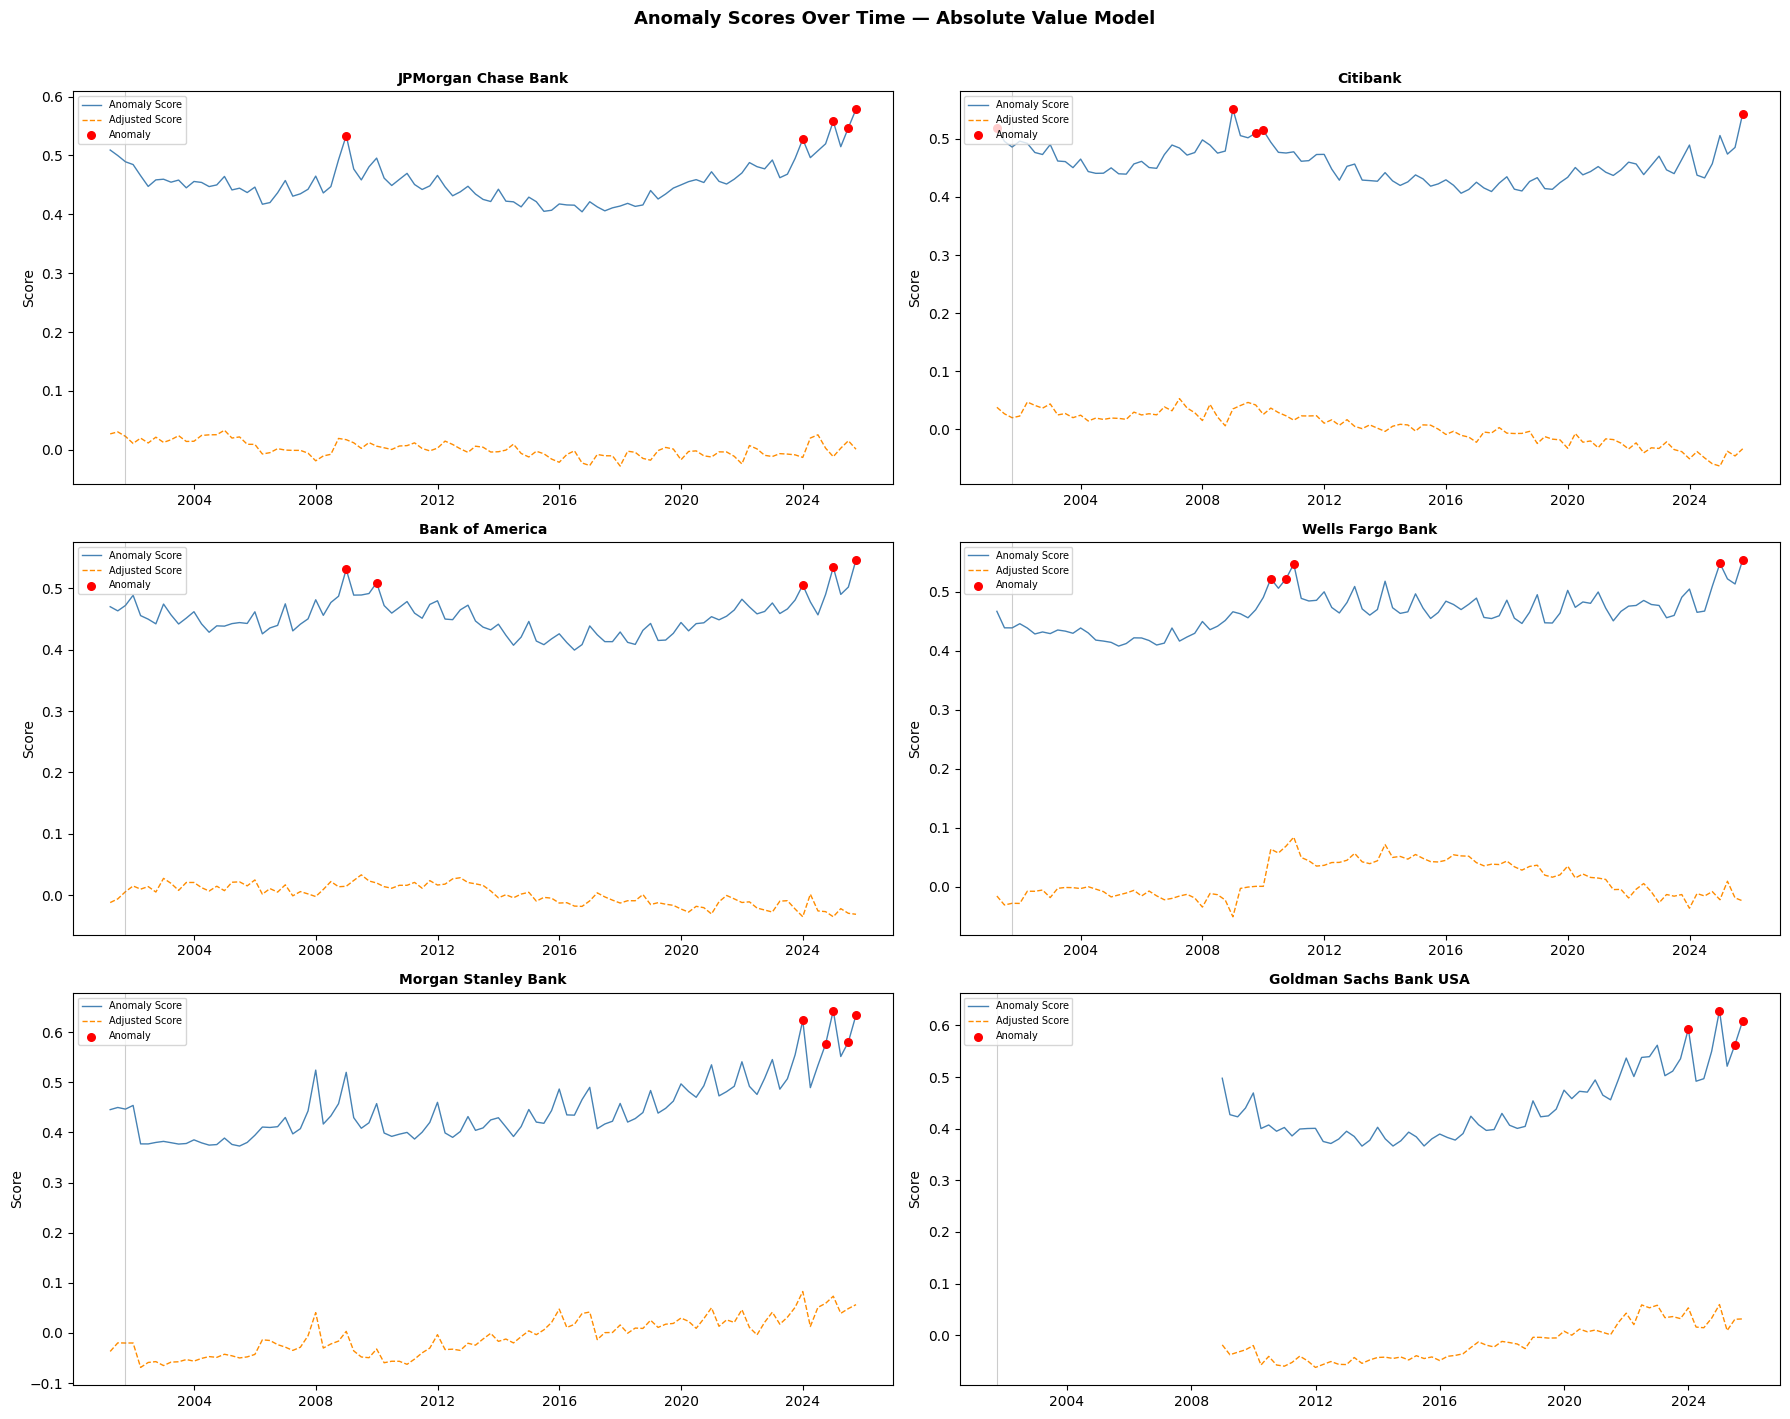

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=False)
axes = axes.flatten()

for idx, (bank_id, df) in enumerate(bank_dfs.items()):
    ax   = axes[idx]
    name = BANK_NAMES[bank_id]
    
    bank_res = results[results['IDRSSD'] == bank_id].copy()
    bank_res['quarter_dt'] = pd.to_datetime(bank_res['quarter'], format='%m/%d/%Y')
    bank_res = bank_res.sort_values('quarter_dt')

    ax.plot(bank_res['quarter_dt'], bank_res['anom_score'],
            color='steelblue', linewidth=1, label='Anomaly Score')
    ax.plot(bank_res['quarter_dt'], bank_res['adjusted_score'],
            color='darkorange', linewidth=1, linestyle='--', label='Adjusted Score')

    anom_mask = bank_res['is_anomaly'] == 1
    ax.scatter(bank_res.loc[anom_mask, 'quarter_dt'],
               bank_res.loc[anom_mask, 'anom_score'],
               color='red', zorder=5, s=30, label='Anomaly')

    # Shade known events
    for q_str, label in KNOWN_EVENTS.items():
        q_dt = pd.to_datetime(q_str, format='%m/%d/%Y')
        ax.axvline(q_dt, color='grey', alpha=0.4, linewidth=0.8)

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Anomaly Scores Over Time — Absolute Value Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 14 — Export Results

In [16]:
'''output_cols = ['bank_name', 'quarter', 'anom_score', 'systemic_score',
               'adjusted_score', 'is_anomaly', 'known_event', 'known_event_label']

results[output_cols].to_csv("iso_absolute_all_results.csv", index=False) #every quarter for every bank with all scores.
primary_findings[output_cols].to_csv("iso_absolute_findings.csv", index=False) # filtered list of anomalies with known macro events removed.
known_events_log[output_cols].to_csv("iso_absolute_known_events_log.csv", index=False) # same as above but only the flagged quarters that landed on a known macro event date. 

print("Saved:")
print("  iso_absolute_all_results.csv")
print("  iso_absolute_findings.csv")
print("  iso_absolute_known_events_log.csv")
print(f"\nPrimary findings: {len(primary_findings)}")
print(f"Known events log: {len(known_events_log)}")'''

'output_cols = [\'bank_name\', \'quarter\', \'anom_score\', \'systemic_score\',\n               \'adjusted_score\', \'is_anomaly\', \'known_event\', \'known_event_label\']\n\nresults[output_cols].to_csv("iso_absolute_all_results.csv", index=False) #every quarter for every bank with all scores.\nprimary_findings[output_cols].to_csv("iso_absolute_findings.csv", index=False) # filtered list of anomalies with known macro events removed.\nknown_events_log[output_cols].to_csv("iso_absolute_known_events_log.csv", index=False) # same as above but only the flagged quarters that landed on a known macro event date. \n\nprint("Saved:")\nprint("  iso_absolute_all_results.csv")\nprint("  iso_absolute_findings.csv")\nprint("  iso_absolute_known_events_log.csv")\nprint(f"\nPrimary findings: {len(primary_findings)}")\nprint(f"Known events log: {len(known_events_log)}")'

---
## Stage 15 — Validation: Known-Event Recall Table

Did the baseline model flag quarters that correspond to documented macro shocks?
A well-functioning anomaly detector should score these quarters highly even if
they are later excluded from the primary findings list.

Recall is computed at **two thresholds**:
- `is_anomaly` flag (top 5 % contamination threshold set at training time)
- Top-10 % of scores for that bank (a looser check)


In [17]:
# ── Known-Event Recall ────────────────────────────────────────────────────────
RECALL_EVENTS = {
    '09/30/2001': '9/11',
    #'12/31/2008': 'GFC Q4-2008',
    #'03/31/2009': 'GFC Q1-2009',
    #'06/30/2009': 'GFC Q2-2009',
    #'03/31/2020': 'COVID Q1-2020',
    #'06/30/2020': 'COVID Q2-2020',
}

recall_rows = []
for bank_id in BANK_NAMES:
    bank_res = results[results['IDRSSD'] == bank_id].copy()
    if bank_res.empty:
        continue
    top10_thresh = bank_res['anom_score'].quantile(0.90)

    for q_str, label in RECALL_EVENTS.items():
        row = bank_res[bank_res['quarter'] == q_str]
        if row.empty:
            flagged_strict = flagged_loose = score = None
            in_data = False
        else:
            score          = row['anom_score'].values[0]
            flagged_strict = int(row['is_anomaly'].values[0])
            flagged_loose  = int(score >= top10_thresh)
            in_data        = True

        recall_rows.append({
            'bank_name':      BANK_NAMES[bank_id],
            'quarter':        q_str,
            'event':          label,
            'in_data':        in_data,
            'anom_score':     round(score, 4) if score is not None else None,
            'flagged_strict': flagged_strict,   # top-5% threshold
            'flagged_loose':  flagged_loose,    # top-10% threshold
        })

recall_df = pd.DataFrame(recall_rows)

# Summary counts
in_data_df = recall_df[recall_df['in_data']==True]
strict_recall = in_data_df['flagged_strict'].mean()
loose_recall  = in_data_df['flagged_loose'].mean()

print("Known-Event Recall Table")
print("=" * 85)
print(recall_df[recall_df['in_data']==True]
      .sort_values(['event','bank_name'])
      [['bank_name','quarter','event','anom_score','flagged_strict','flagged_loose']]
      .to_string(index=False))
print()
print(f"Strict recall (top-5 % flag) : {strict_recall:.1%}  "
      f"({in_data_df['flagged_strict'].sum()}/{len(in_data_df)} bank-event pairs)")
print(f"Loose  recall (top-10% flag) : {loose_recall:.1%}  "
      f"({in_data_df['flagged_loose'].sum()}/{len(in_data_df)} bank-event pairs)")
print()

# Per-event summary
print("Recall by event:")
event_recall = (in_data_df.groupby('event')
                [['flagged_strict','flagged_loose']].mean().round(2))
print(event_recall.to_string())


Known-Event Recall Table
          bank_name    quarter event  anom_score  flagged_strict  flagged_loose
    Bank of America 09/30/2001  9/11      0.4722             0.0            0.0
           Citibank 09/30/2001  9/11      0.4860             0.0            0.0
JPMorgan Chase Bank 09/30/2001  9/11      0.4893             0.0            0.0
Morgan Stanley Bank 09/30/2001  9/11      0.4464             0.0            0.0
   Wells Fargo Bank 09/30/2001  9/11      0.4385             0.0            0.0

Strict recall (top-5 % flag) : 0.0%  (0.0/5 bank-event pairs)
Loose  recall (top-10% flag) : 0.0%  (0.0/5 bank-event pairs)

Recall by event:
       flagged_strict  flagged_loose
event                               
9/11              0.0            0.0


---
## Stage 16 — Validation: Stability Test (Multi-Seed)

Isolation Forest builds random trees — scores can shift across random seeds.
A finding that only appears under one seed is fragile; one that persists across
many seeds is robust.

**Method**: re-run the full baseline pipeline with 20 different seeds.
For each top-20 primary finding, record:
- Mean anomaly score across seeds
- Standard deviation of anomaly score
- How many seeds flagged it as `is_anomaly = 1` (flip rate)


In [18]:
# ── Stability Test ────────────────────────────────────────────────────────────
STABILITY_SEEDS = [16481003, 42, 123, 999, 2024, 7, 314, 1776, 8675309,
                   101, 2001, 2008, 2020, 555, 1234, 9999, 31415, 27182,
                   11111, 66666]

# We only evaluate the top-20 primary findings from the baseline
top20_keys = (primary_findings.head(20)[['IDRSSD','quarter']]
              .apply(tuple, axis=1).tolist())

# seed → per-observation scores
seed_records = []  # list of dicts {IDRSSD, quarter, seed, score, is_anom}

print(f"Running {len(STABILITY_SEEDS)} seeds × {len(bank_dfs)} banks...")

for seed in STABILITY_SEEDS:
    for bank_id, df in bank_dfs.items():
        X = df.values
        pipe_s = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("iso",     IsolationForest(n_estimators=200,
                                        contamination=0.05,
                                        random_state=seed)),
        ])
        pipe_s.fit(X)
        scores   = -pipe_s.named_steps["iso"].score_samples(pipe_s[:-1].transform(X))
        is_anom  = (pipe_s.predict(X) == -1).astype(int)
        quarters = df.index.strftime("%m/%d/%Y")

        for q, sc, ia in zip(quarters, scores, is_anom):
            if (bank_id, q) in top20_keys:
                seed_records.append({
                    'IDRSSD':    bank_id,
                    'bank_name': BANK_NAMES[bank_id],
                    'quarter':   q,
                    'seed':      seed,
                    'score':     sc,
                    'is_anom':   ia,
                })

seed_df = pd.DataFrame(seed_records)

stability = (seed_df.groupby(['IDRSSD','bank_name','quarter'])
             .agg(
                 mean_score  = ('score',   'mean'),
                 std_score   = ('score',   'std'),
                 n_seeds     = ('score',   'count'),
                 seeds_flagged = ('is_anom','sum'),
             )
             .reset_index())
stability['flag_rate']    = stability['seeds_flagged'] / stability['n_seeds']
stability['volatile']     = stability['flag_rate'].apply(
                                lambda r: '⚠ FLIP' if 0.15 < r < 0.85 else '')

# Merge baseline score for reference
stability = stability.merge(
    primary_findings[['IDRSSD','quarter','adjusted_score']].rename(
        columns={'adjusted_score':'baseline_adj_score'}),
    on=['IDRSSD','quarter'], how='left'
).sort_values('baseline_adj_score', ascending=False).reset_index(drop=True)

stability['rank'] = stability.index + 1

print("\nStability Table — Top 20 Primary Findings")
print("=" * 95)
print(stability[['rank','bank_name','quarter','baseline_adj_score',
                 'mean_score','std_score','flag_rate','volatile']]
      .rename(columns={
          'baseline_adj_score':'base_adj',
          'mean_score':'mean_sc',
          'std_score':'std_sc',
          'flag_rate':'flag_rt',
      })
      .to_string(index=False))
print()
print(f"Stable findings   (flag_rate ≥ 0.85) : "
      f"{(stability['flag_rate'] >= 0.85).sum()} / {len(stability)}")
print(f"Volatile findings (0.15 < rate < 0.85): "
      f"{stability['volatile'].str.contains('FLIP').sum()} / {len(stability)}")
print(f"Consistently normal (flag_rate ≤ 0.15): "
      f"{(stability['flag_rate'] <= 0.15).sum()} / {len(stability)}")


Running 20 seeds × 6 banks...

Stability Table — Top 20 Primary Findings
 rank              bank_name    quarter  base_adj  mean_sc   std_sc  flag_rt volatile
    1       Wells Fargo Bank 12/31/2010  0.084008 0.538797 0.010764     0.95         
    2    Morgan Stanley Bank 12/31/2023  0.082677 0.607118 0.009141     1.00         
    3    Morgan Stanley Bank 12/31/2024  0.073315 0.650587 0.008319     1.00         
    4       Wells Fargo Bank 09/30/2010  0.068907 0.521131 0.007650     0.75   ⚠ FLIP
    5       Wells Fargo Bank 03/31/2010  0.063687 0.528910 0.009781     0.80   ⚠ FLIP
    6 Goldman Sachs Bank USA 12/31/2024  0.059330 0.628609 0.007353     1.00         
    7    Morgan Stanley Bank 09/30/2024  0.058988 0.566515 0.007716     0.80   ⚠ FLIP
    8    Morgan Stanley Bank 09/30/2025  0.056465 0.629157 0.008008     1.00         
    9 Goldman Sachs Bank USA 12/31/2023  0.052930 0.592990 0.007983     1.00         
   10    Morgan Stanley Bank 06/30/2025  0.048576 0.575456 0.007882

---
## Stage 17 — Validation: Precision Audit (Manual Ground-Truth Labels)

The 20 highest-ranked primary findings (by `adjusted_score`) are listed below
with a pre-filled `TRUE_POSITIVE` dictionary.

**Instructions — edit the dict in the code cell below:**
- Set `True`  → you found an external narrative that supports the flag
  (earnings surprise, balance-sheet restructuring, regulatory action, etc.)
- Set `False` → no plausible explanation found; likely a data artefact or
  model noise
- Leave `None` → not yet researched

After editing, re-run the cell to see precision, false-positive rate, and a
summary table.


In [20]:
# ── Precision Audit ───────────────────────────────────────────────────────────
# Edit the values below: True = confirmed finding, False = no story found, None = TBD
# Key format: "BANK NAME | MM/DD/YYYY"

top20_audit = primary_findings.head(20)[['bank_name','quarter','adjusted_score']].copy()
top20_audit['key'] = top20_audit['bank_name'] + ' | ' + top20_audit['quarter']

TRUE_POSITIVE = {
    # ── JPMorgan Chase Bank ──────────────────────────────────────────────────
     'Morgan Stanley Bank | 12/31/2023': True,
    
    # ── Citibank ─────────────────────────────────────────────────────────────
    'Citibank | 03/31/2001': False,
    
    # ── Bank of America ───────────────────────────────────────────────────────

    # ── Wells Fargo Bank ──────────────────────────────────────────────────────
    'Wells Fargo Bank | 12/31/2010': True
    # ── Morgan Stanley Bank ───────────────────────────────────────────────────

    # ── Goldman Sachs Bank USA ────────────────────────────────────────────────
}

# Print the audit table so you can copy keys into the dict above
print("Top 20 Primary Findings — Precision Audit Table")
print("=" * 72)
print(f"{'Rank':<5} {'Key (copy → dict)':<55} {'Adj Score':>9}")
print("-" * 72)
for i, row in top20_audit.iterrows():
    rank = top20_audit.index.get_loc(i) + 1
    label = TRUE_POSITIVE.get(row['key'])
    tag   = ' ✓' if label is True else (' ✗' if label is False else '')
    print(f"{rank:<5} {row['key']:<55} {row['adjusted_score']:>9.4f}{tag}")

# ── Summary stats (only on labelled entries) ──────────────────────────────────
labelled = {k: v for k, v in TRUE_POSITIVE.items() if v is not None}
if labelled:
    tp = sum(1 for v in labelled.values() if v is True)
    fp = sum(1 for v in labelled.values() if v is False)
    precision = tp / (tp + fp) if (tp + fp) > 0 else None
    print()
    print(f"Labelled : {len(labelled)} / 20")
    print(f"True Pos : {tp}   False Pos : {fp}")
    print(f"Precision: {precision:.1%}" if precision is not None else "Precision: n/a")
else:
    print()
    print("No labels entered yet — populate TRUE_POSITIVE dict and re-run.")


Top 20 Primary Findings — Precision Audit Table
Rank  Key (copy → dict)                                       Adj Score
------------------------------------------------------------------------
1     Wells Fargo Bank | 12/31/2010                              0.0840 ✓
2     Morgan Stanley Bank | 12/31/2023                           0.0827 ✓
3     Morgan Stanley Bank | 12/31/2024                           0.0733
4     Wells Fargo Bank | 09/30/2010                              0.0689
5     Wells Fargo Bank | 03/31/2010                              0.0637
6     Goldman Sachs Bank USA | 12/31/2024                        0.0593
7     Morgan Stanley Bank | 09/30/2024                           0.0590
8     Morgan Stanley Bank | 09/30/2025                           0.0565
9     Goldman Sachs Bank USA | 12/31/2023                        0.0529
10    Morgan Stanley Bank | 06/30/2025                           0.0486
11    Citibank | 09/30/2009                                      0.0416
12    Citib